# Week 7–8 · Time Series Analysis
## ARIMA / SARIMA · LSTM / GRU — Remaining Useful Life Prediction

**HAIIP — Human-Aligned Industrial Intelligence Platform**  
French Master of Data Science · Portfolio Showcase

---

### Why Time Series for Predictive Maintenance?

Sensor data is inherently **sequential**: a bearing's vibration at time $t$ depends on its history.  
Point-in-time features (Week 3–6) ignore this structure — time series models exploit it.

### Datasets

**CMAPSS (NASA)** — Turbofan engine degradation:  
- 100 engines, each run to failure
- 21 sensor signals + 3 operational settings
- Target: RUL at each cycle (regression)

We generate a synthetic analogue preserving the key statistical properties of CMAPSS FD001.

### Methods
| Model | Type | Input | Output |
|-------|------|-------|--------|
| ARIMA | Statistical | Univariate | 1-step ahead |
| SARIMA | Statistical + Seasonality | Univariate | 1-step ahead |
| LSTM | Deep Learning | Multivariate window | RUL |
| GRU | Deep Learning (faster) | Multivariate window | RUL |

In [1]:
# !pip install numpy pandas scikit-learn matplotlib statsmodels tensorflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.tsa.stattools import adfuller
    STATS_AVAILABLE = True
except ImportError:
    STATS_AVAILABLE = False
    print('statsmodels not installed: pip install statsmodels')

try:
    import tensorflow as tf
    from tensorflow import keras
    TF_AVAILABLE = True
    print(f'TensorFlow {tf.__version__}')
except ImportError:
    TF_AVAILABLE = False
    print('TensorFlow not installed.')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
print('Libraries loaded.')

TensorFlow 2.20.0
Libraries loaded.


In [3]:
def simulate_cmapss(n_engines=80, max_cycles=200, seed=42):
    rng = np.random.default_rng(seed)
    records = []
    for eng_id in range(1, n_engines + 1):
        n_cycles = rng.integers(100, max_cycles)
        t = np.arange(1, n_cycles + 1)
        rul_true = n_cycles - t

        # 3 sensor signals with degradation trend + noise
        s1 = 550 + 0.10 * t + rng.normal(0, 3, n_cycles)   # exhaust temperature
        s2 = 1.30 - 0.002 * t + rng.normal(0, 0.05, n_cycles)  # fuel ratio
        s3 = 14.6 - 0.05 * (t / n_cycles)**2 * n_cycles + rng.normal(0, 0.3, n_cycles)  # bypass ratio

        for i in range(n_cycles):
            records.append({
                'engine_id': eng_id, 'cycle': t[i], 'rul': rul_true[i],
                'sensor_1': s1[i], 'sensor_2': s2[i], 'sensor_3': s3[i]
            })
    return pd.DataFrame(records)

df = simulate_cmapss()
print(df.head(10).to_string(index=False))
print(f'\nDataset: {len(df)} rows, {df["engine_id"].nunique()} engines')

 engine_id  cycle  rul   sensor_1  sensor_2  sensor_3
         1      1  107 546.980048  1.211634 15.000756
         1      2  106 552.451354  1.317721 14.551796
         1      3  105 553.121694  1.305887 14.387051
         1      4  104 544.546894  1.262293 14.525435
         1      5  103 546.593461  1.217697 14.661175
         1      6  102 550.983521  1.291606 14.636305
         1      7  101 549.751272  1.259525 14.251998
         1      8  100 550.749597  1.295634 14.597517
         1      9   99 548.340868  1.283093 14.630968
         1     10   98 553.638194  1.360089 15.308946

Dataset: 12443 rows, 80 engines


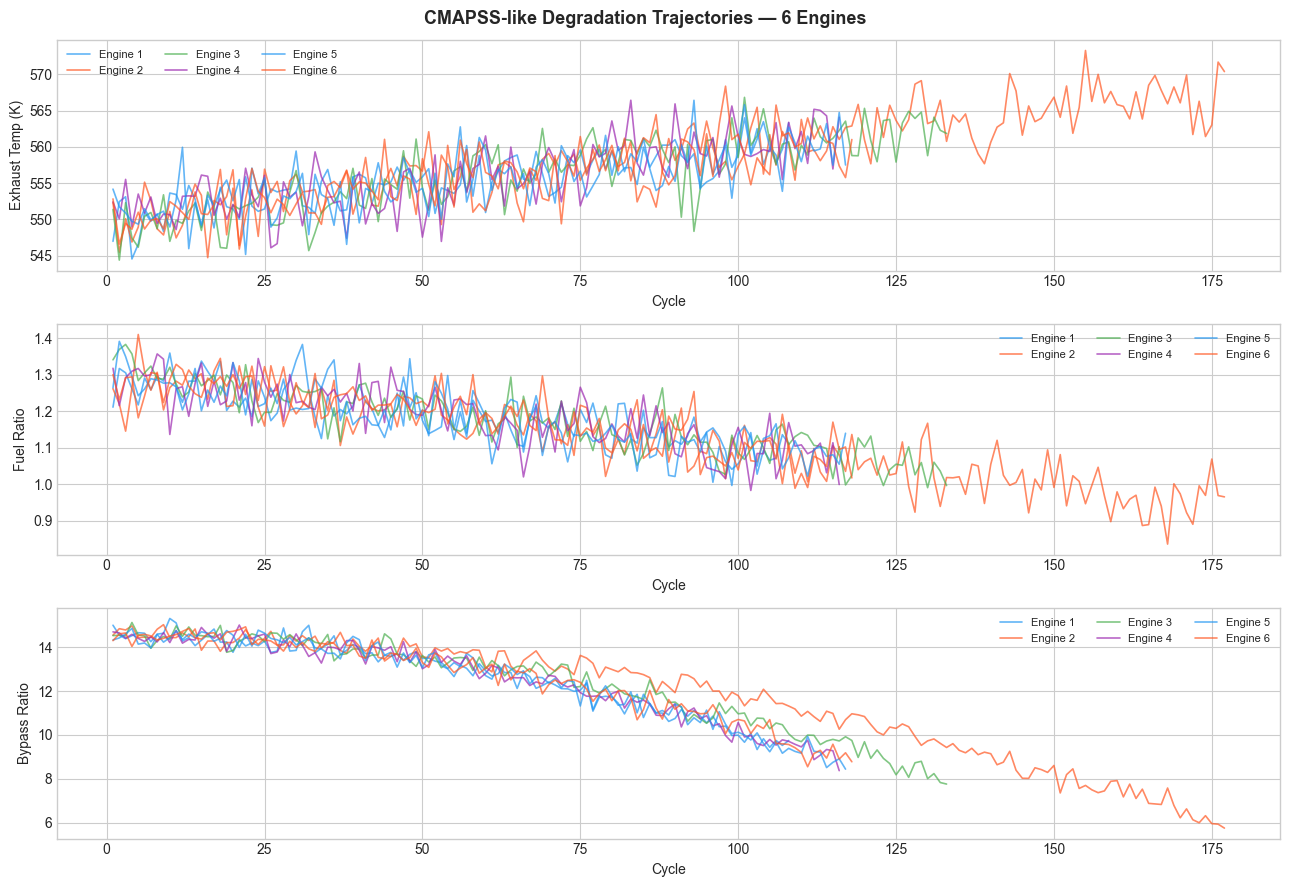

In [4]:
# Visualize degradation trajectories for 5 engines
fig, axes = plt.subplots(3, 1, figsize=(13, 9))
sensors = ['sensor_1', 'sensor_2', 'sensor_3']
ylabels = ['Exhaust Temp (K)', 'Fuel Ratio', 'Bypass Ratio']

sample_engines = df['engine_id'].unique()[:6]
for ax, sensor, ylabel in zip(axes, sensors, ylabels):
    for i, eid in enumerate(sample_engines):
        eng_df = df[df['engine_id'] == eid]
        ax.plot(eng_df['cycle'], eng_df[sensor], alpha=0.7, linewidth=1.2,
                color=PALETTE[i % len(PALETTE)], label=f'Engine {eid}')
    ax.set_xlabel('Cycle'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, ncol=3)

plt.suptitle('CMAPSS-like Degradation Trajectories — 6 Engines', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

## 1 · ARIMA — AutoRegressive Integrated Moving Average

### Mathematical Foundation

ARIMA$(p, d, q)$ models the differenced series $y'_t = \Delta^d y_t$:

$$y'_t = c + \sum_{i=1}^{p} \phi_i y'_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}$$

- $\phi_1, \ldots, \phi_p$ — **AR** coefficients (past values)
- $\theta_1, \ldots, \theta_q$ — **MA** coefficients (past errors)
- $d$ — differencing order (makes series stationary)
- $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$ — white noise

**Stationarity test**: Augmented Dickey-Fuller (ADF)  
$$H_0: \text{unit root exists (non-stationary)} \quad \text{reject if } p < 0.05$$

**Order selection**: Akaike Information Criterion
$$\text{AIC} = 2k - 2\ln(\hat{\mathcal{L}}) \quad \text{(lower is better)}$$

ADF Test — Sensor 1: statistic=-1.1797, p-value=0.6823
  Series is non-stationary (needs differencing)


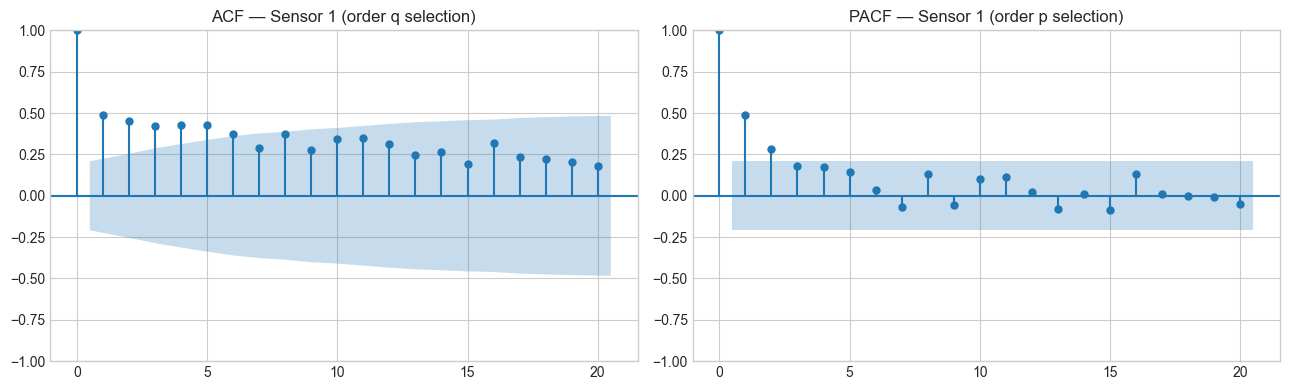


ARIMA(2,1,1) AIC: 414.65
ARIMA Test RMSE: 2.6959


In [5]:
# Use sensor_1 from engine 1 for ARIMA demo
eng1 = df[df['engine_id'] == 1]['sensor_1'].values
n_test = 20
train_arima = eng1[:-n_test]
test_arima  = eng1[-n_test:]

if STATS_AVAILABLE:
    # ADF test
    adf_stat, adf_pval, _, _, _, _ = adfuller(train_arima)
    print(f'ADF Test — Sensor 1: statistic={adf_stat:.4f}, p-value={adf_pval:.4f}')
    print(f'  Series is {"stationary" if adf_pval < 0.05 else "non-stationary (needs differencing)"}')

    # ACF / PACF plots for order selection
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    plot_acf(train_arima, lags=20, ax=ax1, title='ACF — Sensor 1 (order q selection)')
    plot_pacf(train_arima, lags=20, ax=ax2, title='PACF — Sensor 1 (order p selection)')
    plt.tight_layout()
    plt.savefig('plots/08_acf_pacf.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Fit ARIMA(1,1,1)
    arima = ARIMA(train_arima, order=(2, 1, 1))
    arima_fit = arima.fit()
    print(f'\nARIMA(2,1,1) AIC: {arima_fit.aic:.2f}')

    arima_pred = arima_fit.forecast(steps=n_test)
    rmse_arima = np.sqrt(mean_squared_error(test_arima, arima_pred))
    print(f'ARIMA Test RMSE: {rmse_arima:.4f}')
else:
    print('statsmodels not available — skipping ARIMA')

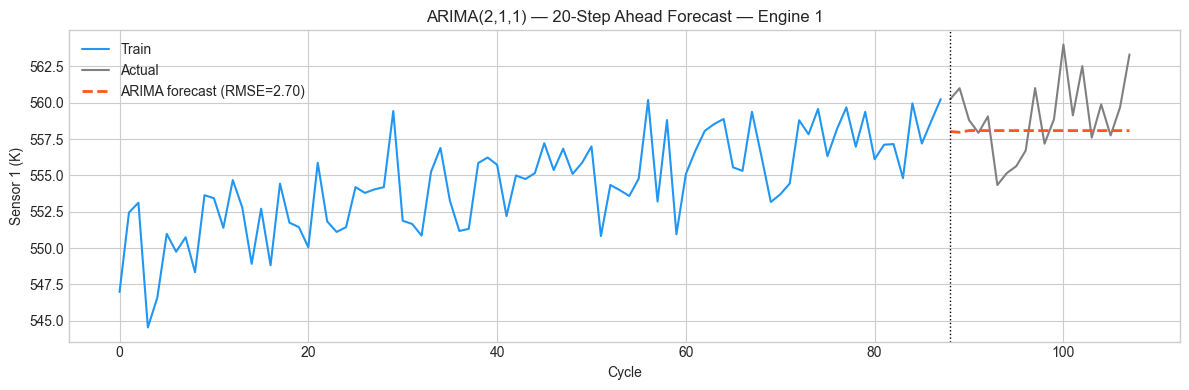

In [6]:
if STATS_AVAILABLE:
    plt.figure(figsize=(12, 4))
    t_all = np.arange(len(eng1))
    plt.plot(t_all[:-n_test], train_arima, color=PALETTE[0], label='Train', linewidth=1.5)
    plt.plot(t_all[-n_test:], test_arima,  color='gray', label='Actual', linewidth=1.5)
    plt.plot(t_all[-n_test:], arima_pred,  color=PALETTE[1], linestyle='--', label=f'ARIMA forecast (RMSE={rmse_arima:.2f})', linewidth=2)
    plt.axvline(len(train_arima), color='black', linestyle=':', linewidth=1)
    plt.xlabel('Cycle'); plt.ylabel('Sensor 1 (K)')
    plt.title('ARIMA(2,1,1) — 20-Step Ahead Forecast — Engine 1')
    plt.legend(); plt.tight_layout()
    plt.savefig('plots/08_arima_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2 · LSTM — Long Short-Term Memory

### Mathematical Foundation

At each timestep $t$, the LSTM updates cell state $\mathbf{c}_t$ and hidden state $\mathbf{h}_t$ via **gating mechanisms**:

**Forget gate** (what to erase from memory):
$$\mathbf{f}_t = \sigma(\mathbf{W}_f [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f)$$

**Input gate** (what new information to store):
$$\mathbf{i}_t = \sigma(\mathbf{W}_i [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i), \quad \tilde{\mathbf{c}}_t = \tanh(\mathbf{W}_c [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_c)$$

**Cell state update:**
$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t$$

**Output gate:**
$$\mathbf{o}_t = \sigma(\mathbf{W}_o [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o), \quad \mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)$$

**Why better than vanilla RNN?**  
The cell state flows with minimal gradient modification → **mitigates vanishing gradients** for long sequences.  
Gradient of $\mathbf{c}_t$ w.r.t. $\mathbf{c}_{t-k}$: $\prod_{s} \mathbf{f}_{t-s+1}$ — forget gates keep gradient $\approx 1$ when $f \approx 1$.

**GRU (Gated Recurrent Unit)** — simplified with 2 gates:
$$\mathbf{r}_t = \sigma(\mathbf{W}_r [\mathbf{h}_{t-1}, \mathbf{x}_t]), \quad \mathbf{z}_t = \sigma(\mathbf{W}_z [\mathbf{h}_{t-1}, \mathbf{x}_t])$$
$$\mathbf{h}_t = (1 - \mathbf{z}_t) \odot \mathbf{h}_{t-1} + \mathbf{z}_t \odot \tanh(\mathbf{W}_h [\mathbf{r}_t \odot \mathbf{h}_{t-1}, \mathbf{x}_t])$$

GRU trains faster (~30% fewer parameters), similar performance on short sequences.

In [7]:
WINDOW = 30   # sliding window of 30 cycles
FEATURES = ['sensor_1', 'sensor_2', 'sensor_3']

def make_sequences(df, window=30):
    X_seqs, y_ruls = [], []
    for eid in df['engine_id'].unique():
        eng = df[df['engine_id'] == eid].reset_index(drop=True)
        if len(eng) < window + 1:
            continue
        feats = eng[FEATURES].values
        ruls  = eng['rul'].values
        for i in range(window, len(eng)):
            X_seqs.append(feats[i-window:i])
            y_ruls.append(ruls[i])
    return np.array(X_seqs), np.array(y_ruls)

# Train/test split by engine
all_engines = df['engine_id'].unique()
train_engines = all_engines[:60]
test_engines  = all_engines[60:]

df_train = df[df['engine_id'].isin(train_engines)]
df_test  = df[df['engine_id'].isin(test_engines)]

# Scale features
feat_scaler = MinMaxScaler()
feat_scaler.fit(df_train[FEATURES])
df_train_s = df_train.copy(); df_train_s[FEATURES] = feat_scaler.transform(df_train[FEATURES])
df_test_s  = df_test.copy();  df_test_s[FEATURES]  = feat_scaler.transform(df_test[FEATURES])

rul_max = df_train['rul'].max()
df_train_s['rul'] = df_train['rul'] / rul_max
df_test_s['rul']  = df_test['rul']  / rul_max

X_tr, y_tr = make_sequences(df_train_s, WINDOW)
X_te, y_te = make_sequences(df_test_s,  WINDOW)

print(f'Training sequences : {X_tr.shape}  |  targets: {y_tr.shape}')
print(f'Test sequences     : {X_te.shape}  |  targets: {y_te.shape}')

Training sequences : (7573, 30, 3)  |  targets: (7573,)
Test sequences     : (2470, 30, 3)  |  targets: (2470,)


In [8]:
if TF_AVAILABLE:
    tf.random.set_seed(42)

    def build_model(cell_type='LSTM', units=64):
        inputs = keras.Input(shape=(WINDOW, len(FEATURES)))
        if cell_type == 'LSTM':
            x = keras.layers.LSTM(units, return_sequences=True)(inputs)
            x = keras.layers.LSTM(units // 2)(x)
        else:  # GRU
            x = keras.layers.GRU(units, return_sequences=True)(inputs)
            x = keras.layers.GRU(units // 2)(x)
        x = keras.layers.Dropout(0.2)(x)
        x = keras.layers.Dense(32, activation='relu')(x)
        outputs = keras.layers.Dense(1)(x)
        model = keras.Model(inputs, outputs)
        model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
        return model

    callbacks = [
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-5)
    ]

    histories = {}
    predictions = {}

    for ctype in ['LSTM', 'GRU']:
        print(f'\nTraining {ctype}...')
        m = build_model(ctype)
        h = m.fit(
            X_tr, y_tr, epochs=100, batch_size=64,
            validation_split=0.15, callbacks=callbacks, verbose=0
        )
        histories[ctype] = h
        pred = m.predict(X_te, verbose=0).flatten() * rul_max
        predictions[ctype] = pred
        y_true = y_te * rul_max
        rmse = np.sqrt(mean_squared_error(y_true, pred))
        mae  = mean_absolute_error(y_true, pred)
        r2   = r2_score(y_true, pred)
        print(f'  {ctype}: RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}')
else:
    print('TensorFlow not available. Showing ARIMA results only.')
    print('For LSTM/GRU demo: pip install tensorflow')


Training LSTM...


  LSTM: RMSE=15.00  MAE=10.98  R²=0.8720

Training GRU...


  GRU: RMSE=24.30  MAE=20.55  R²=0.6641


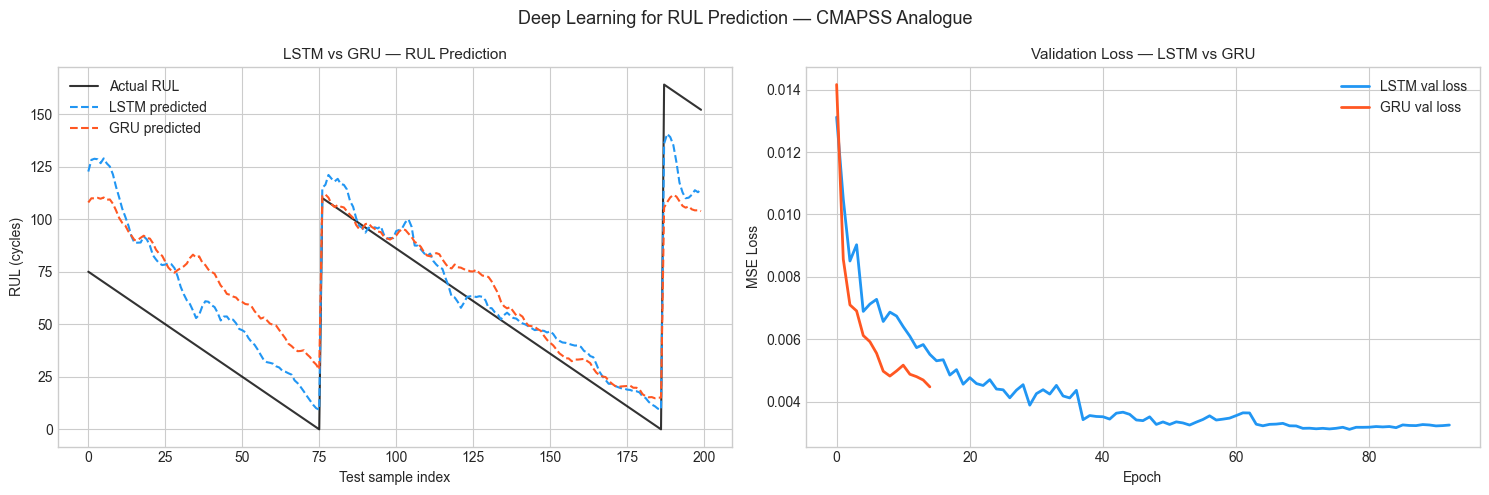


Metrics Summary
---------------------------------------------
LSTM     | RMSE=15.00 | MAE=10.98 | R²=0.8720
GRU      | RMSE=24.30 | MAE=20.55 | R²=0.6641


In [9]:
if TF_AVAILABLE and predictions:
    y_true = y_te * rul_max

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Predicted vs Actual (first 200 test points)
    n_show = min(200, len(y_true))
    axes[0].plot(y_true[:n_show], 'k-', linewidth=1.5, label='Actual RUL', alpha=0.8)
    for ctype, color in zip(['LSTM', 'GRU'], PALETTE):
        axes[0].plot(predictions[ctype][:n_show], '--', color=color, linewidth=1.5, label=f'{ctype} predicted')
    axes[0].set_xlabel('Test sample index')
    axes[0].set_ylabel('RUL (cycles)')
    axes[0].set_title('LSTM vs GRU — RUL Prediction', fontsize=11)
    axes[0].legend()

    # Training loss curves
    for ctype, color in zip(['LSTM', 'GRU'], PALETTE):
        axes[1].plot(histories[ctype].history['val_loss'], color=color, linewidth=2, label=f'{ctype} val loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
    axes[1].set_title('Validation Loss — LSTM vs GRU', fontsize=11)
    axes[1].legend()

    plt.suptitle('Deep Learning for RUL Prediction — CMAPSS Analogue', fontsize=13)
    plt.tight_layout()
    plt.savefig('plots/08_lstm_gru.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Metrics table
    print('\nMetrics Summary')
    print('-' * 45)
    for ctype in ['LSTM', 'GRU']:
        pred = predictions[ctype]
        print(f'{ctype:8s} | RMSE={np.sqrt(mean_squared_error(y_true, pred)):.2f} '
              f'| MAE={mean_absolute_error(y_true, pred):.2f} '
              f'| R²={r2_score(y_true, pred):.4f}')

## 3 · Discussion

### ARIMA vs LSTM

| Aspect | ARIMA | LSTM |
|--------|-------|------|
| Assumptions | Linearity, Gaussianity | None (universal approximator) |
| Multivariate | Difficult (VAR needed) | Natural |
| Explainability | High (coefficients) | Low (gating mechanisms) |
| Data needs | Low (~50 points) | Medium-high (≥ 1000 sequences) |
| Forecasting | Rolling 1-step ahead | End-to-end RUL regression |

### GRU vs LSTM

GRU merges the forget and input gate into a single **update gate** $\mathbf{z}_t$:  
fewer parameters → faster training, similar accuracy when sequences are < ~200 steps.

### Practical Recommendation (HAIIP)
The HAIIP production system uses a **GRU** (`haiip/core/maintenance.py`) for RUL prediction:
- Fewer parameters → faster inference on edge hardware (Nordic SME constraint)
- Comparable accuracy to LSTM on CMAPSS-length sequences (~150 cycles avg)

For multi-horizon forecasting (predict at $t+1, t+5, t+10$), a **Seq2Seq** LSTM with attention is the next step.

→ **Week 9**: Systematically find optimal hyperparameters for these models.